## 3.7 양자 데이터 압축 (Quantum Data Compression)

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import random_statevector, DensityMatrix, entropy
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 무작위 양자 상태 생성
state = random_statevector(2**3)

In [3]:
# 상태를 밀도행렬로 변환
density_matrix = DensityMatrix(state)

In [4]:
# 폰 노이만 엔트로피 계산
von_neumann_entropy = entropy(density_matrix)

print(f"Von Neumann Entropy: {von_neumann_entropy}")

Von Neumann Entropy: 2.1075484553645693e-15


In [5]:
# 큐비트 3개 + 고전 비트 3개로 양자 회로 생성
qc = QuantumCircuit(3, 3)

In [6]:
# 무작위 상태로 회로 초기화
qc.initialize(state, [0, 1, 2])

In [7]:
# 모든 큐비트 측정
qc.measure([0, 1, 2], [0, 1, 2])

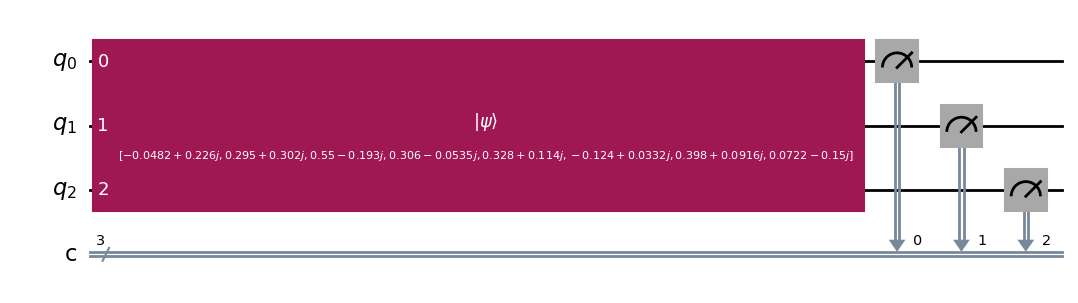

In [8]:
# 회로 그리기
qc.draw('mpl')
plt.show()

In [9]:
# Qiskit Aer 시뮬레이터 초기화
simulator = AerSimulator()

In [10]:
# 시뮬레이터용으로 회로 트랜스파일
compiled_circuit = transpile(qc, simulator)

In [11]:
# Qiskit Aer 시뮬레이터에서 회로 실행
job = simulator.run(compiled_circuit, shots=1024)

In [12]:
# 결과 얻기
result = job.result()

In [13]:
# 측정 결과 얻기
counts = result.get_counts(compiled_circuit)

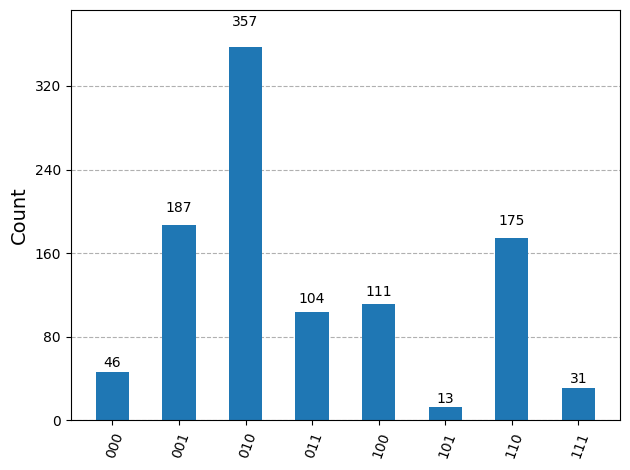

In [14]:
# 히스토그램 그리기
plot_histogram(counts)
plt.show()